
# Test Compressed BOLD5000 Data — Self-Contained Workflow

**Goal:** Prove that the `.npz` files produced by `preprocess.py` contain all the metadata
needed to drive the full pipeline — trial labels, session mapping, parcel names, and S3 keys.

For each subject (CSI1–CSI4), this notebook:
1. Loads `{subject}_schaefer400.npz` — betas, labels, sessions, local_idxs, parcel_names
2. Verifies all Schaefer-400 node metadata is intact
3. Picks 3 random trials and shows their full label info and derived S3/local paths
4. Uses `sessions[i]` + `local_idxs[i]` to load the raw beta volume from local HDD
5. Visualises each beta map at fixed MNI z-slices with labels in the title


## 1. Import Required Libraries

In [12]:
import os
import re
import random
import subprocess
import tempfile
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import nibabel as nib
import nilearn
from nilearn import image, plotting
import matplotlib.pyplot as plt


## 2. Configuration

In [13]:

# ── Paths ──────────────────────────────────────────────────────────────────
PROCESSED_DIR   = "processed_data"    # output of preprocess.py
OUTPUT_PLOT_DIR = "test_plots"        # where PNGs are saved

SUBJECTS        = ["CSI1", "CSI2", "CSI3", "CSI4"]
TRIALS_PER_SUBJ = 3
RANDOM_SEED     = 42

# Fixed MNI z-coordinates (mm) — same for every plot so slices are comparable
FIXED_Z_COORDS  = (-40, -15, 10, 35, 60)

os.makedirs(OUTPUT_PLOT_DIR, exist_ok=True)
random.seed(RANDOM_SEED)



## 3. Helper Functions


In [14]:

# ── Raw data location ─────────────────────────────────────────────────────────
BOLD5000_DIR = "/media/hdd/BOLD5000"


def local_path_for_beta(subject: str, session: int) -> str:

    fname = f"{subject}_GLMbetas-TYPED-FITHRF-GLMDENOISE-RR_ses-{session:02d}.nii.gz"
    return os.path.join(BOLD5000_DIR, fname)



  #Load a single 3D beta volume directly from the local HDD.
def load_beta_volume(subject: str, session: int, local_idx: int,
                     correct_affine: np.ndarray) -> nib.Nifti1Image:
  
    nii_path = local_path_for_beta(subject, session)
    proxy    = nib.load(nii_path)
    vol3d    = np.asarray(proxy.dataobj[..., local_idx], dtype=np.float32).copy()
    return nib.Nifti1Image(vol3d, correct_affine)


def get_correct_affine(subject: str) -> np.ndarray:
    mask_path = os.path.join(BOLD5000_DIR, f"{subject}_brainmask.nii.gz")
    return nib.load(mask_path).affine


print(" Local-file helper functions defined")
print(f"  Raw data root : {BOLD5000_DIR}")
print(f"  Path pattern  : {{subject}}_GLMbetas-TYPED-FITHRF-GLMDENOISE-RR_ses-NN.nii.gz")


 Local-file helper functions defined
  Raw data root : /media/hdd/BOLD5000
  Path pattern  : {subject}_GLMbetas-TYPED-FITHRF-GLMDENOISE-RR_ses-NN.nii.gz


## 4. Load Compressed Data — Verify All Fields

Load `_schaefer400.npz` for each subject and confirm every baked-in field is present and correct.

In [15]:
subject_data = {}   # subject -> dict with all npz fields + sampled trial_indices

for subject in SUBJECTS:
    npz_path = os.path.join(PROCESSED_DIR, subject, f"{subject}_schaefer400.npz")
    if not os.path.exists(npz_path):
        print(f"  ⚠ {subject}: {npz_path} not found, skipping.")
        continue

    npz = np.load(npz_path, allow_pickle=True)

    # Verify all expected fields are present
    required = ["betas", "imgnames", "subject", "sessions", "local_idxs",
                "dataset_sources", "labels", "parcel_names"]
    missing = [f for f in required if f not in npz]
    if missing:
        print(f"  ✗ {subject}: missing fields {missing}")
        continue

    betas           = npz["betas"]         
    imgnames        = npz["imgnames"]        
    sessions        = npz["sessions"]      
    local_idxs      = npz["local_idxs"]    
    dataset_sources = npz["dataset_sources"] 
    labels          = npz["labels"]        
    parcel_names    = npz["parcel_names"]  

    n_trials = len(imgnames)
    trial_indices = sorted(random.sample(range(n_trials), TRIALS_PER_SUBJ))

    subject_data[subject] = {
        "betas"          : betas,
        "imgnames"       : imgnames,
        "sessions"       : sessions,
        "local_idxs"     : local_idxs,
        "dataset_sources": dataset_sources,
        "labels"         : labels,
        "parcel_names"   : parcel_names,
        "trial_indices"  : trial_indices,
    }

    multi_label = sum(1 for lbl in labels if len(lbl) > 1)
    print(f"\n{'='*60}")
    print(f"  {subject}  —  {n_trials:,} trials  |  {betas.shape[1]} Schaefer parcels")
    print(f"{'='*60}")
    print(f"  betas shape      : {betas.shape}  dtype={betas.dtype}")
    print(f"  sessions range   : {sessions.min()} – {sessions.max()}")
    print(f"  dataset breakdown: " +
          "  ".join(f"{src}={np.sum(dataset_sources == src)}"
                    for src in ["ImageNet", "COCO", "Scene"]))
    print(f"  multi-label COCO : {multi_label} trials have >1 object label")
    print(f"  parcel_names[0]  : {parcel_names[0]}")
    print(f"  parcel_names[-1] : {parcel_names[-1]}")
    print(f"  sampled trials   : {trial_indices}")

print(f"\n Loaded {len(subject_data)} subject(s)")


  CSI1  —  5,254 trials  |  400 Schaefer parcels
  betas shape      : (5254, 400)  dtype=float32
  sessions range   : 1 – 15
  dataset breakdown: ImageNet=2051  COCO=2135  Scene=1068
  multi-label COCO : 1462 trials have >1 object label
  parcel_names[0]  : 7Networks_LH_Vis_1
  parcel_names[-1] : 7Networks_RH_Default_pCunPCC_9
  sampled trials   : [204, 912, 5238]

  CSI2  —  5,254 trials  |  400 Schaefer parcels
  betas shape      : (5254, 400)  dtype=float32
  sessions range   : 1 – 15
  dataset breakdown: ImageNet=2051  COCO=2135  Scene=1068
  multi-label COCO : 1462 trials have >1 object label
  parcel_names[0]  : 7Networks_LH_Vis_1
  parcel_names[-1] : 7Networks_RH_Default_pCunPCC_9
  sampled trials   : [1828, 2006, 2253]

  CSI3  —  5,254 trials  |  400 Schaefer parcels
  betas shape      : (5254, 400)  dtype=float32
  sessions range   : 1 – 15
  dataset breakdown: ImageNet=2052  COCO=2133  Scene=1069
  multi-label COCO : 1462 trials have >1 object label
  parcel_names[0]  : 7Ne

## 5. Inspect Sampled Trials — Labels and S3 Paths

In [16]:
for subject, info in subject_data.items():
    print(f"\n{'='*65}")
    print(f"  {subject}")
    print(f"{'='*65}")

    for i in info["trial_indices"]:
        imgname        = info["imgnames"][i]
        dataset_source = info["dataset_sources"][i]
        trial_labels   = info["labels"][i]       # list[str]
        session        = int(info["sessions"][i])
        local_idx      = int(info["local_idxs"][i])

        local_nii = local_path_for_beta(subject, session)

        print(f"\n  trial {i:>4d}")
        print(f"    dataset       : {dataset_source}")
        print(f"    labels        : {trial_labels}")
        print(f"    imgname       : {imgname}")
        print(f"    session       : {session}  |  local_idx: {local_idx}")
        print(f"    local beta    : {local_nii}  [vol {local_idx}]")



  CSI1

  trial  204
    dataset       : COCO
    labels        : ['sheep']
    imgname       : COCO_train2014_000000396550.jpg
    session       : 1  |  local_idx: 204
    local beta    : /media/hdd/BOLD5000/CSI1_GLMbetas-TYPED-FITHRF-GLMDENOISE-RR_ses-01.nii.gz  [vol 204]

  trial  912
    dataset       : ImageNet
    labels        : ['slug']
    imgname       : n01945685_2329.JPEG
    session       : 3  |  local_idx: 172
    local beta    : /media/hdd/BOLD5000/CSI1_GLMbetas-TYPED-FITHRF-GLMDENOISE-RR_ses-03.nii.gz  [vol 172]

  trial 5238
    dataset       : COCO
    labels        : ['bottle', 'dining table', 'person', 'tie', 'cup', 'fork', 'spoon', 'knife', 'chair']
    imgname       : COCO_train2014_000000370802.jpg
    session       : 15  |  local_idx: 354
    local beta    : /media/hdd/BOLD5000/CSI1_GLMbetas-TYPED-FITHRF-GLMDENOISE-RR_ses-15.nii.gz  [vol 354]

  CSI2

  trial 1828
    dataset       : ImageNet
    labels        : ['Dungeness_crab']
    imgname       : n01978287_


## 6. Load Raw Betas from Local HDD and Visualise



  Subject: CSI1

  trial  204  ses-01 vol-204  [COCO]  sheep
  imgname  : COCO_train2014_000000396550.jpg
  local nii: /media/hdd/BOLD5000/CSI1_GLMbetas-TYPED-FITHRF-GLMDENOISE-RR_ses-01.nii.gz
   Built mean background for ses-01
   Built mean background for ses-01
  data range [-13539.39, 12816.16]  vmax=5.98
  data range [-13539.39, 12816.16]  vmax=5.98
   Saved: test_plots/CSI1_trial0204_sheep.png
   Saved: test_plots/CSI1_trial0204_sheep.png


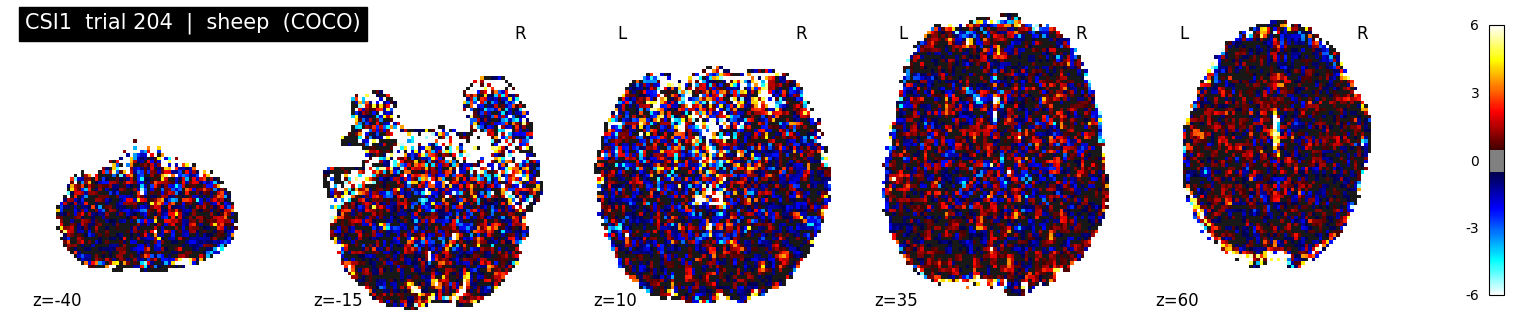


  trial  912  ses-03 vol-172  [ImageNet]  slug
  imgname  : n01945685_2329.JPEG
  local nii: /media/hdd/BOLD5000/CSI1_GLMbetas-TYPED-FITHRF-GLMDENOISE-RR_ses-03.nii.gz
   Built mean background for ses-03
   Built mean background for ses-03
  data range [-329267.69, 40189.68]  vmax=4.57
  data range [-329267.69, 40189.68]  vmax=4.57
   Saved: test_plots/CSI1_trial0912_slug.png
   Saved: test_plots/CSI1_trial0912_slug.png


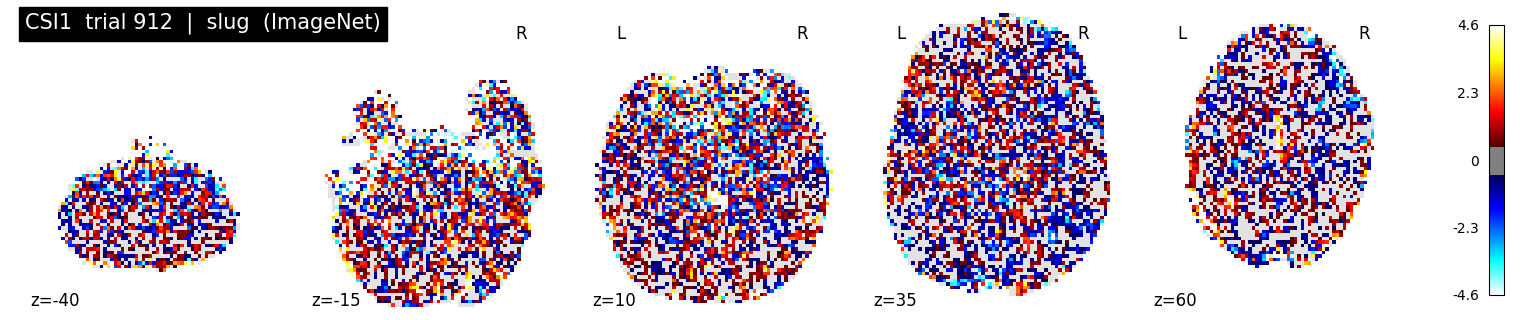


  trial 5238  ses-15 vol-354  [COCO]  bottle | dining table | person | tie | cup | fork | spoon | knife | chair
  imgname  : COCO_train2014_000000370802.jpg
  local nii: /media/hdd/BOLD5000/CSI1_GLMbetas-TYPED-FITHRF-GLMDENOISE-RR_ses-15.nii.gz
   Built mean background for ses-15
   Built mean background for ses-15
  data range [-3666.22, 1564.34]  vmax=4.19
  data range [-3666.22, 1564.34]  vmax=4.19
   Saved: test_plots/CSI1_trial5238_bottle___dining_table___person___tie___cup___fork_.png
   Saved: test_plots/CSI1_trial5238_bottle___dining_table___person___tie___cup___fork_.png


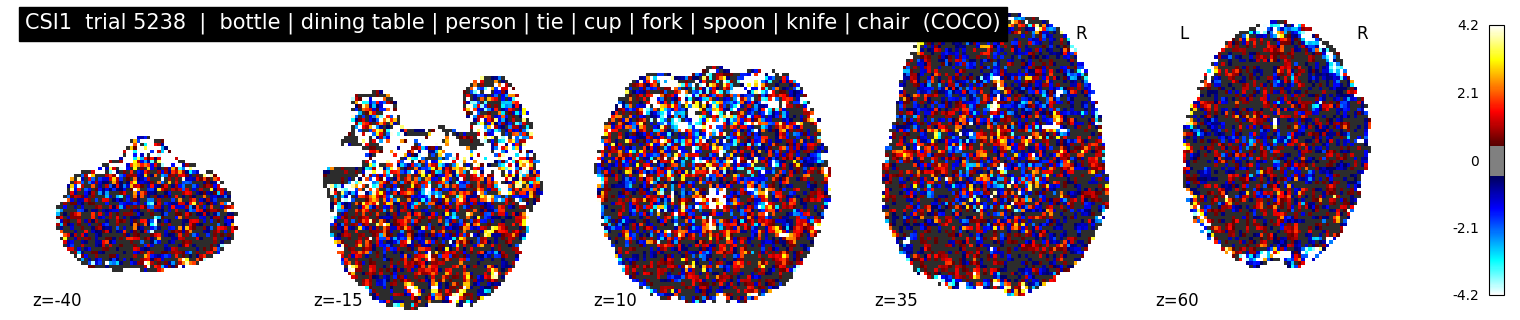


  Subject: CSI2

  trial 1828  ses-06 vol- 15  [ImageNet]  Dungeness_crab
  imgname  : n01978287_6155.JPEG
  local nii: /media/hdd/BOLD5000/CSI2_GLMbetas-TYPED-FITHRF-GLMDENOISE-RR_ses-06.nii.gz
   Built mean background for ses-06
  data range [-1654.17, 1267.72]  vmax=4.52
   Built mean background for ses-06
  data range [-1654.17, 1267.72]  vmax=4.52
   Saved: test_plots/CSI2_trial1828_Dungeness_crab.png
   Saved: test_plots/CSI2_trial1828_Dungeness_crab.png


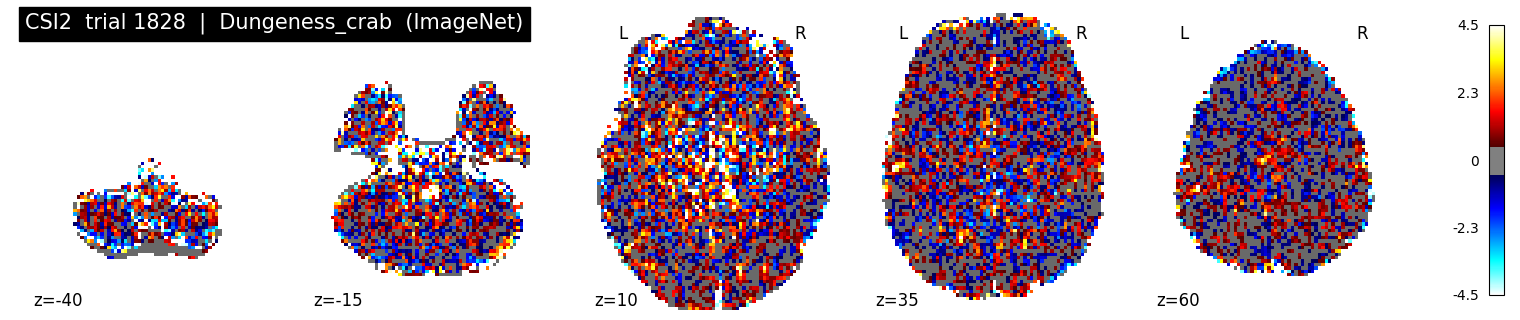


  trial 2006  ses-06 vol-193  [ImageNet]  guenon
  imgname  : n02484975_6608.JPEG
  local nii: /media/hdd/BOLD5000/CSI2_GLMbetas-TYPED-FITHRF-GLMDENOISE-RR_ses-06.nii.gz
  data range [-3419.88, 110726.39]  vmax=4.63
  data range [-3419.88, 110726.39]  vmax=4.63
   Saved: test_plots/CSI2_trial2006_guenon.png
   Saved: test_plots/CSI2_trial2006_guenon.png


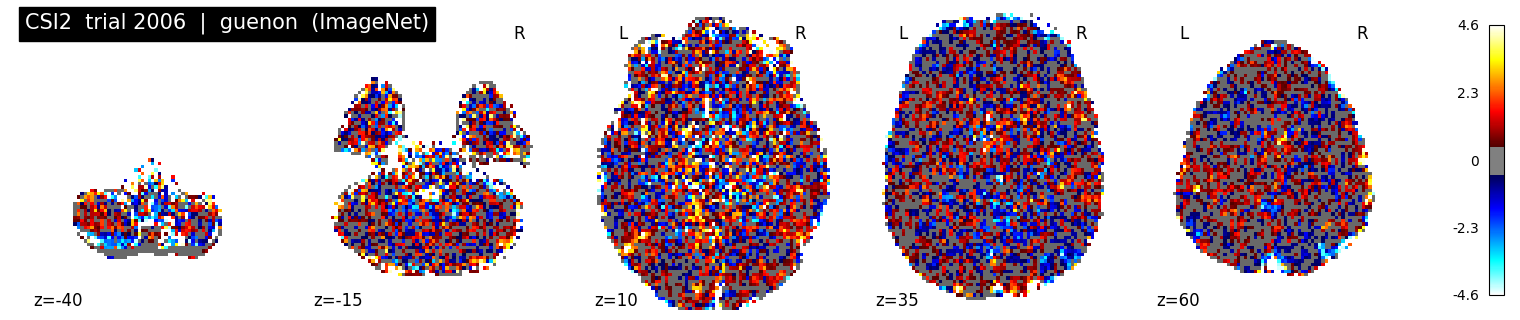


  trial 2253  ses-07 vol-107  [ImageNet]  ping-pong_ball
  imgname  : n03942813_5685.JPEG
  local nii: /media/hdd/BOLD5000/CSI2_GLMbetas-TYPED-FITHRF-GLMDENOISE-RR_ses-07.nii.gz
   Built mean background for ses-07
   Built mean background for ses-07
  data range [-31900.29, 4992.48]  vmax=4.87
  data range [-31900.29, 4992.48]  vmax=4.87
   Saved: test_plots/CSI2_trial2253_ping-pong_ball.png
   Saved: test_plots/CSI2_trial2253_ping-pong_ball.png


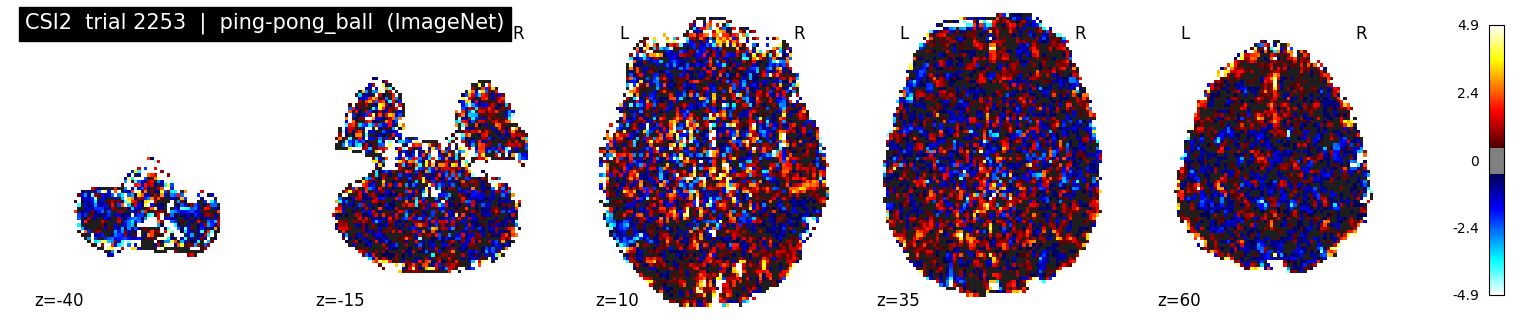


  Subject: CSI3

  trial  839  ses-03 vol-136  [ImageNet]  admiral
  imgname  : n02276258_5118.JPEG
  local nii: /media/hdd/BOLD5000/CSI3_GLMbetas-TYPED-FITHRF-GLMDENOISE-RR_ses-03.nii.gz
   Built mean background for ses-03
   Built mean background for ses-03
  data range [-16629.40, 87223.87]  vmax=5.91
  data range [-16629.40, 87223.87]  vmax=5.91
   Saved: test_plots/CSI3_trial0839_admiral.png
   Saved: test_plots/CSI3_trial0839_admiral.png


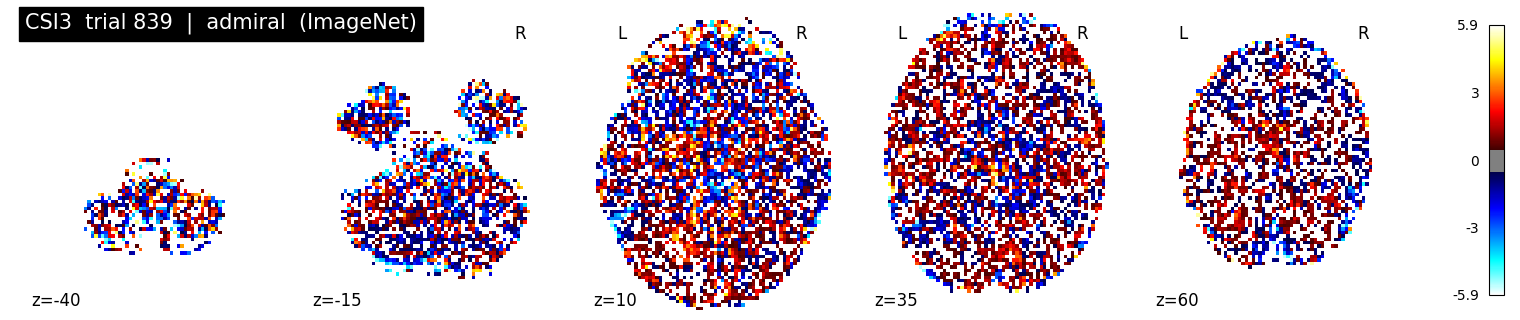


  trial 1143  ses-04 vol- 70  [COCO]  person | bench | scissors | handbag
  imgname  : COCO_train2014_000000195816.jpg
  local nii: /media/hdd/BOLD5000/CSI3_GLMbetas-TYPED-FITHRF-GLMDENOISE-RR_ses-04.nii.gz
   Built mean background for ses-04
   Built mean background for ses-04
  data range [-954.29, 702.48]  vmax=5.33
  data range [-954.29, 702.48]  vmax=5.33
   Saved: test_plots/CSI3_trial1143_person___bench___scissors___handbag.png
   Saved: test_plots/CSI3_trial1143_person___bench___scissors___handbag.png


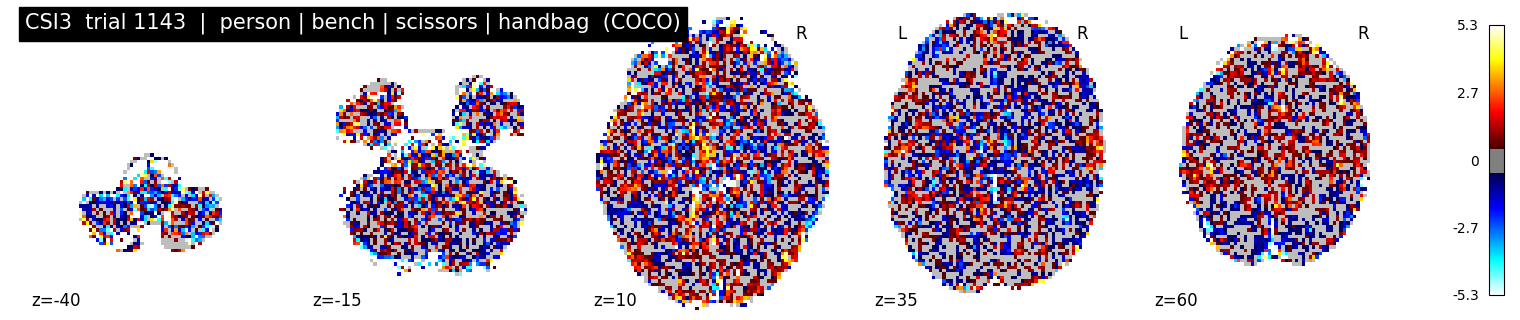


  trial 4467  ses-13 vol-249  [COCO]  potted plant | keyboard | tv | book | chair | vase
  imgname  : COCO_train2014_000000443575.jpg
  local nii: /media/hdd/BOLD5000/CSI3_GLMbetas-TYPED-FITHRF-GLMDENOISE-RR_ses-13.nii.gz
   Built mean background for ses-13
   Built mean background for ses-13
  data range [-48303.71, 1753.35]  vmax=4.91
  data range [-48303.71, 1753.35]  vmax=4.91
   Saved: test_plots/CSI3_trial4467_potted_plant___keyboard___tv___book___chair___vase.png
   Saved: test_plots/CSI3_trial4467_potted_plant___keyboard___tv___book___chair___vase.png


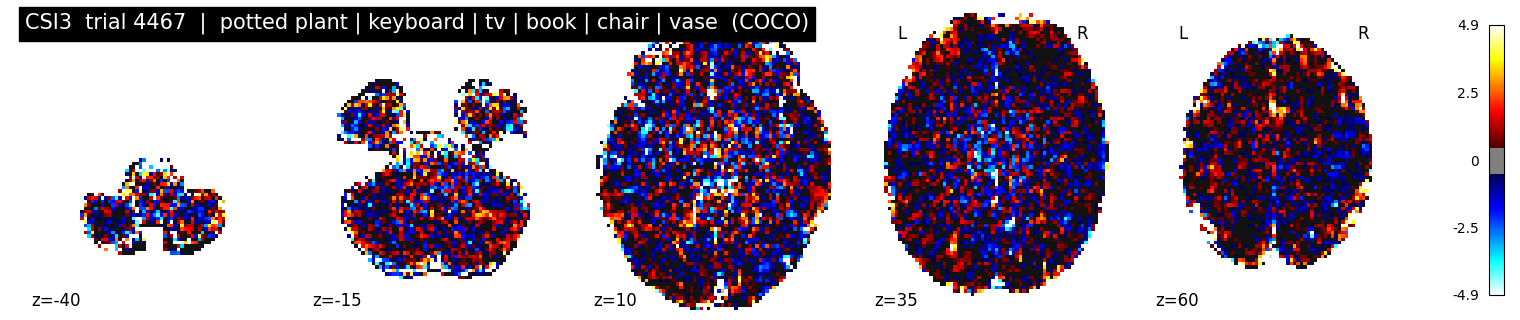


  Subject: CSI4

  trial  356  ses-01 vol-356  [COCO]  person | hot dog
  imgname  : COCO_train2014_000000309192.jpg
  local nii: /media/hdd/BOLD5000/CSI4_GLMbetas-TYPED-FITHRF-GLMDENOISE-RR_ses-01.nii.gz
   Built mean background for ses-01
   Built mean background for ses-01
  data range [-6810.20, 360701.28]  vmax=5.17
  data range [-6810.20, 360701.28]  vmax=5.17
   Saved: test_plots/CSI4_trial0356_person___hot_dog.png
   Saved: test_plots/CSI4_trial0356_person___hot_dog.png


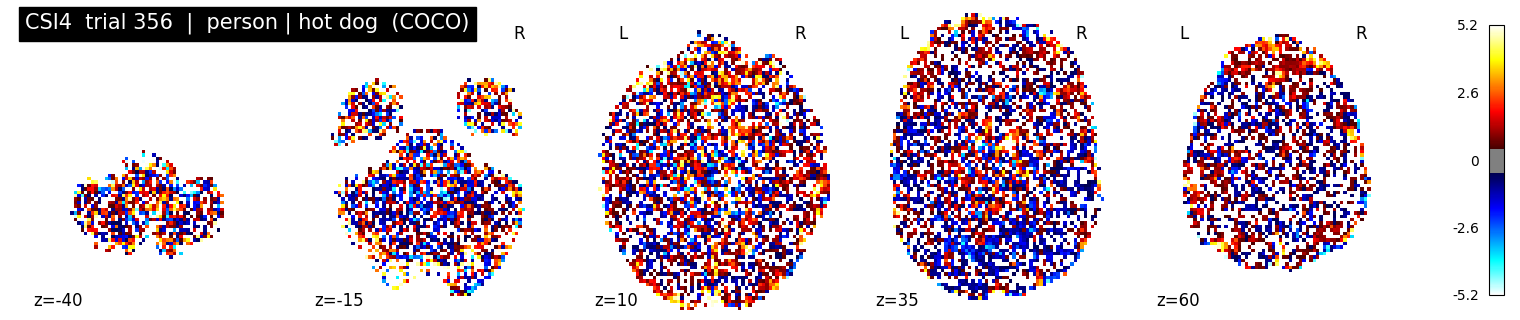


  trial 1728  ses-05 vol-322  [ImageNet]  tape_player
  imgname  : n04392985_7175.JPEG
  local nii: /media/hdd/BOLD5000/CSI4_GLMbetas-TYPED-FITHRF-GLMDENOISE-RR_ses-05.nii.gz
   Built mean background for ses-05
   Built mean background for ses-05
  data range [-8425.11, 34996.35]  vmax=5.41
  data range [-8425.11, 34996.35]  vmax=5.41
   Saved: test_plots/CSI4_trial1728_tape_player.png
   Saved: test_plots/CSI4_trial1728_tape_player.png


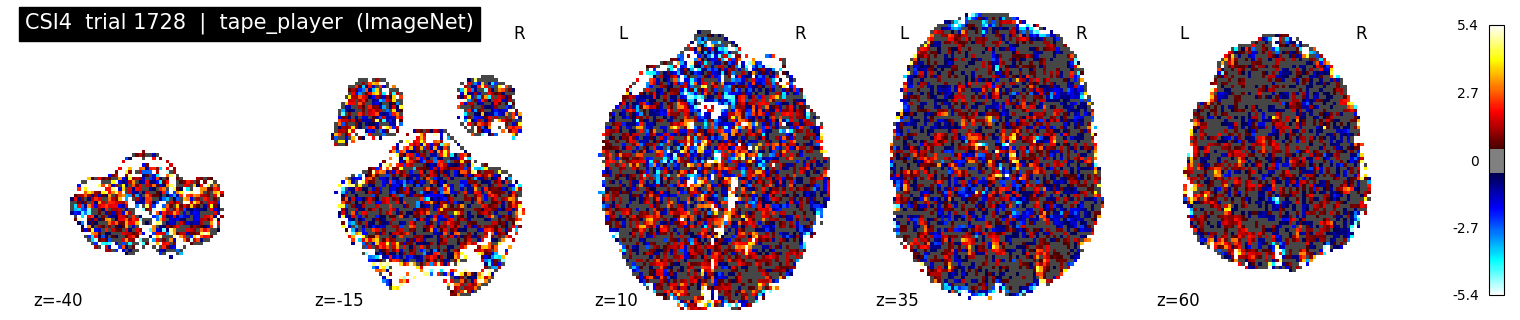


  trial 2418  ses-08 vol- 13  [ImageNet]  bonnet
  imgname  : n02869837_28668.JPEG
  local nii: /media/hdd/BOLD5000/CSI4_GLMbetas-TYPED-FITHRF-GLMDENOISE-RR_ses-08.nii.gz
   Built mean background for ses-08
  data range [-1513.95, 3142.02]  vmax=4.58
   Built mean background for ses-08
  data range [-1513.95, 3142.02]  vmax=4.58
   Saved: test_plots/CSI4_trial2418_bonnet.png
   Saved: test_plots/CSI4_trial2418_bonnet.png


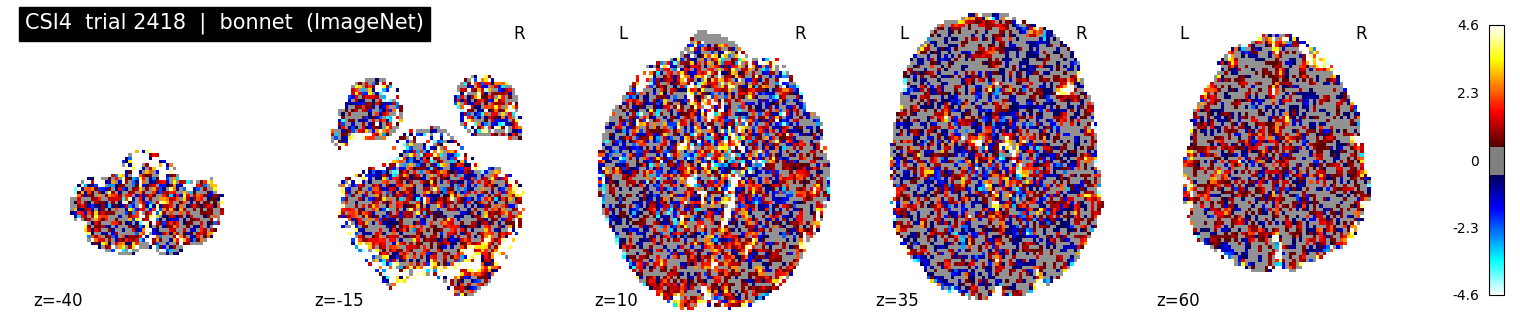


  All done  |  z-slices: (-40, -15, 10, 35, 60)
  Plots saved to: test_plots/


In [17]:

# ── Visualization loop ────────────────────────────────────────────────────────
# All path construction uses info baked into the .npz — no hard-coded paths.
#
# For each sampled trial:
#  1. Read session  = sessions[i]    from .npz  → build local .nii.gz path
#  2. Read local_idx = local_idxs[i] from .npz  → extract single 3D volume
#  3. Read labels[i]                 from .npz  → put in plot title

for subject, info in subject_data.items():
    correct_affine = get_correct_affine(subject)
    trial_indices  = info["trial_indices"]

    print(f"\n{'='*65}")
    print(f"  Subject: {subject}")
    print(f"{'='*65}")

    # Cache mean background per session (each .nii.gz is ~270 MB — load once)
    mean_beta_cache: dict[int, nib.Nifti1Image] = {}

    for i in trial_indices:
        # ── All metadata straight from .npz ───────────────────────────────
        imgname        = info["imgnames"][i]
        dataset_source = info["dataset_sources"][i]
        trial_labels   = info["labels"][i]          # list[str]
        session        = int(info["sessions"][i])
        local_idx      = int(info["local_idxs"][i])

        labels_str = " | ".join(trial_labels)

        print(f"\n  trial {i:>4d}  ses-{session:02d} vol-{local_idx:>3d}  "
              f"[{dataset_source}]  {labels_str}")
        print(f"  imgname  : {imgname}")
        print(f"  local nii: {local_path_for_beta(subject, session)}")

        # ── Build mean background once per session (cached) ───────────────
        if session not in mean_beta_cache:
            nii_path   = local_path_for_beta(subject, session)
            raw_4d     = nib.load(nii_path)
            patched_4d = nib.Nifti1Image(
                np.asarray(raw_4d.dataobj, dtype=np.float32), correct_affine
            )
            mean_beta_cache[session] = image.mean_img(patched_4d)
            print(f"   Built mean background for ses-{session:02d}")

        mean_bg = mean_beta_cache[session]

        # ── Extract single 3D volume (local_idxs[i] from .npz) ───────────
        beta_3d   = load_beta_volume(subject, session, local_idx, correct_affine)
        data_flat = beta_3d.get_fdata().ravel()
        data_flat = data_flat[np.isfinite(data_flat)]
        vmax      = float(np.percentile(np.abs(data_flat), 95))
        print(f"  data range [{data_flat.min():.2f}, {data_flat.max():.2f}]  vmax={vmax:.2f}")

        # ── Plot ──────────────────────────────────────────────────────────
        title = f"{subject}  trial {i}  |  {labels_str}  ({dataset_source})"
        fig = plt.figure(figsize=(15, 3))
        plotting.plot_stat_map(
            beta_3d,
            bg_img       = mean_bg,
            display_mode = 'z',
            cut_coords   = FIXED_Z_COORDS,
            title        = title,
            threshold    = 0.5,
            vmax         = vmax,
            cmap         = 'cold_hot',
            figure       = fig,
            colorbar     = True,
            black_bg     = False,
            dim          = -0.5,
        )

        safe_label = re.sub(r'[^\w\-]', '_', labels_str)[:50]
        out_png = os.path.join(OUTPUT_PLOT_DIR,
                               f"{subject}_trial{i:04d}_{safe_label}.png")
        plt.savefig(out_png, dpi=150, bbox_inches='tight')
        print(f"   Saved: {out_png}")
        plt.show()

print(f"\n{'='*65}")
print(f"  All done  |  z-slices: {FIXED_Z_COORDS}")
print(f"  Plots saved to: {OUTPUT_PLOT_DIR}/")
print(f"{'='*65}")
